In [1]:
import itertools

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

from ant.centralised import P4
from ant.decentralised.direct import GreedyAgent, ProportionalAgent
from ant.decentralised.special_strategies import EgalitarianAgent, ImitationAgent, MixedAgent, PettyAgent, SatisficingAgent
from ant.market import BaseAgent, Market


In [2]:
market_size = 20
simulation_length = 400
num_repeats = 30

pure_strategies = {
    "Proportional": ProportionalAgent,
    "Greedy": GreedyAgent,
    "Egalitarian": EgalitarianAgent,
    "Petty": PettyAgent,
    "Imitation": ImitationAgent,
    "Satisficing": SatisficingAgent,
}
graph_types = ["complete", "random", "grid", "scale-free", "small-world"]

all_results = {
    "All_Strategies_Mix": {gtype: [] for gtype in graph_types}
}


In [3]:
for repeat in range(num_repeats):
    print(f"Running repeat {repeat + 1}/{num_repeats}...")
    current_seed = 657849724 + repeat

    rnd_seed = current_seed
    random_graph = nx.gnp_random_graph(market_size, 0.2, seed=rnd_seed)
    while not nx.is_connected(random_graph):
        rnd_seed += 1000
        random_graph = nx.gnp_random_graph(market_size, 0.2, seed=rnd_seed)

    graphs = {
        "complete": nx.complete_graph(market_size),
        "random": random_graph,
        "grid": nx.convert_node_labels_to_integers(nx.grid_2d_graph(int(market_size / 4), 4)),
        "scale-free": nx.barabasi_albert_graph(market_size, 1, seed=current_seed),
        "small-world": nx.connected_watts_strogatz_graph(market_size, int(market_size / 2), 0.05, seed=current_seed),
    }

    all_strategy_classes = list(pure_strategies.values())
    num_strategies = len(all_strategy_classes)

    for graph_type, graph in graphs.items():
        pair_key = "All_Strategies_Mix"

        mixed_agents = []
        for i in range(market_size):
            rng = np.random.default_rng(current_seed + i)
            agent_weights = rng.uniform(0, 1, num_strategies)
            agent_weights /= agent_weights.sum()  # Normalize to sum to 1
            mixed_agents.append(
                MixedAgent(
                    id=i,
                    seed=current_seed + i,
                    strategies=all_strategy_classes,
                    weights=agent_weights.tolist(),
                )
            )

        _market = Market(
            market_size,
            graph=graph,
            agents=mixed_agents,
            seed=current_seed,
            agent_type=BaseAgent,
        )

        for agent in _market.agents:
            agent.market = _market
            agent.received = np.zeros(market_size, dtype=float)
            agent.received_history = np.zeros((10000, market_size), dtype=float)

        optimal_aloc, utility_vec = P4(_market)
        _market.set_market_equilibrium(optimal_aloc, utility_vec)

        simulated_state = _market.simulate(simulation_length)
        all_results[pair_key][graph_type].append(simulated_state)


Running repeat 1/30...
Running repeat 2/30...
Running repeat 3/30...
Running repeat 4/30...
Running repeat 5/30...
Running repeat 6/30...
Running repeat 7/30...
Running repeat 8/30...
Running repeat 9/30...
Running repeat 10/30...
Running repeat 11/30...
Running repeat 12/30...
Running repeat 13/30...
Running repeat 14/30...
Running repeat 15/30...
Running repeat 16/30...
Running repeat 17/30...
Running repeat 18/30...
Running repeat 19/30...
Running repeat 20/30...
Running repeat 21/30...
Running repeat 22/30...
Running repeat 23/30...
Running repeat 24/30...
Running repeat 25/30...
Running repeat 26/30...
Running repeat 27/30...
Running repeat 28/30...
Running repeat 29/30...
Running repeat 30/30...


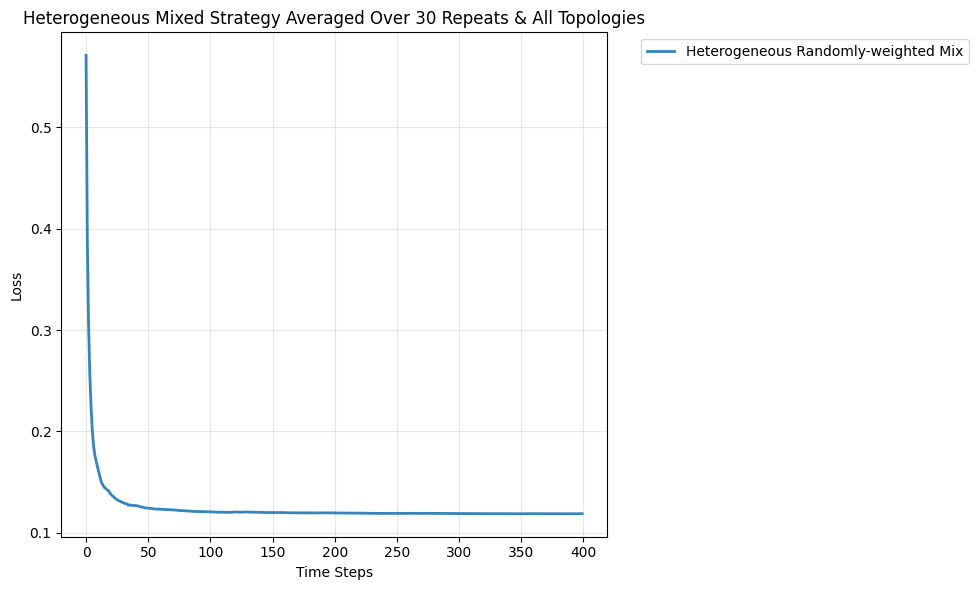

In [7]:
training_period = 0
time_steps = np.arange(training_period, simulation_length)
colors = plt.cm.tab20.colors

plt.figure(figsize=(10, 6))

for idx, mix_name in enumerate(all_results.keys()):
    all_topologies_average = []

    for graph_type in graph_types:
        states_array = np.array(all_results[mix_name][graph_type])
        avg_state = np.mean(states_array, axis=0)
        all_topologies_average.append(avg_state)

    grand_average = np.mean(all_topologies_average, axis=0)

    plt.plot(
        time_steps,
        grand_average[training_period:],
        label="Heterogeneous Randomly-weighted Mix",
        color=colors[idx % len(colors)],
        linewidth=2,
        alpha=0.9,
    )

plt.xlabel("Time Steps")
plt.ylabel("Loss")
plt.title(f"Heterogeneous Mixed Strategy Averaged Over {num_repeats} Repeats & All Topologies")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


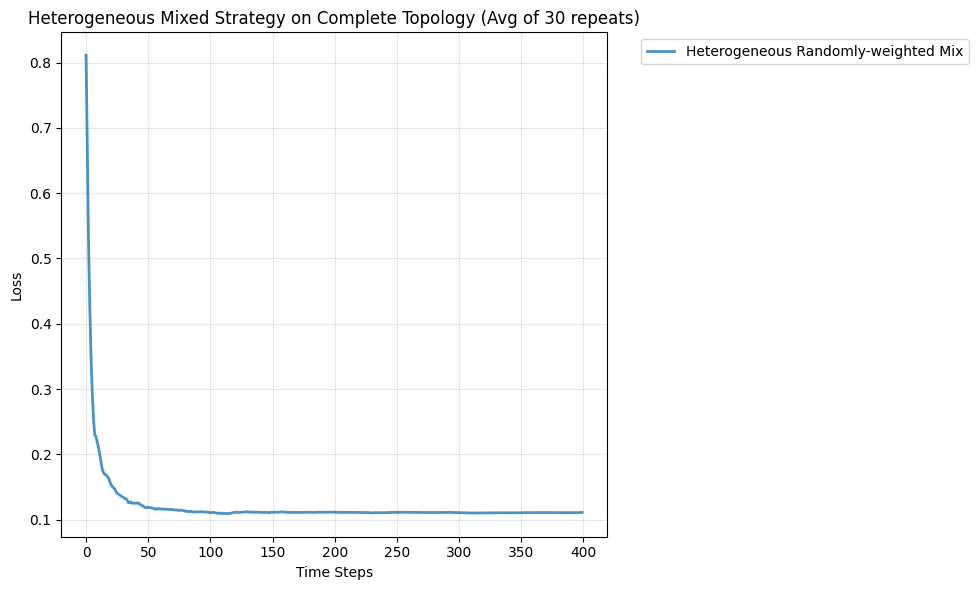

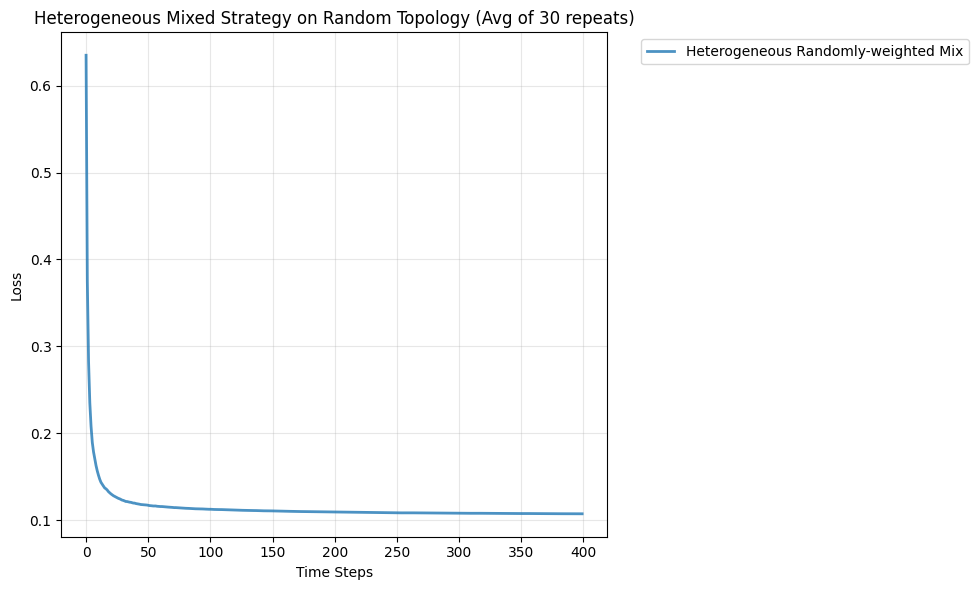

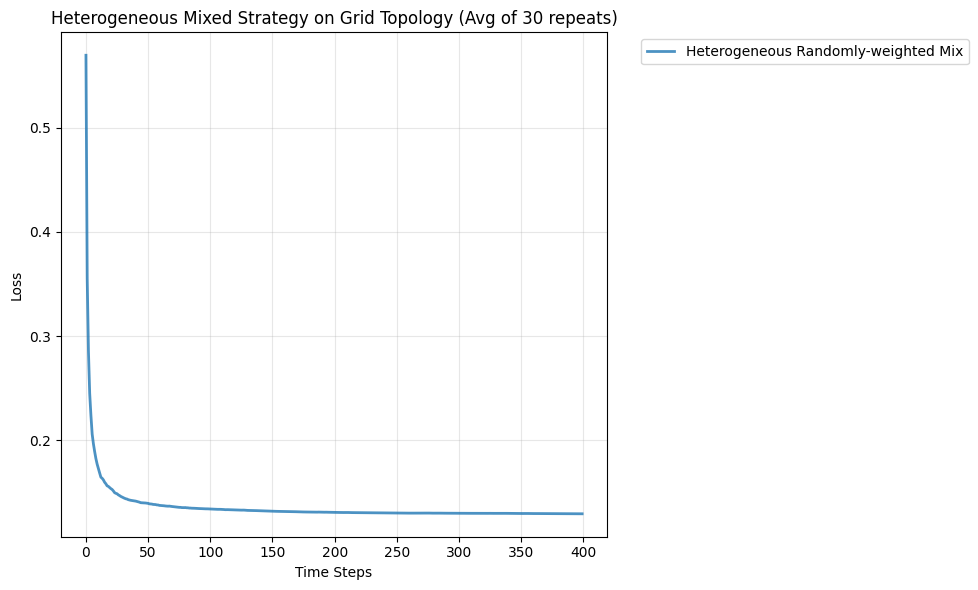

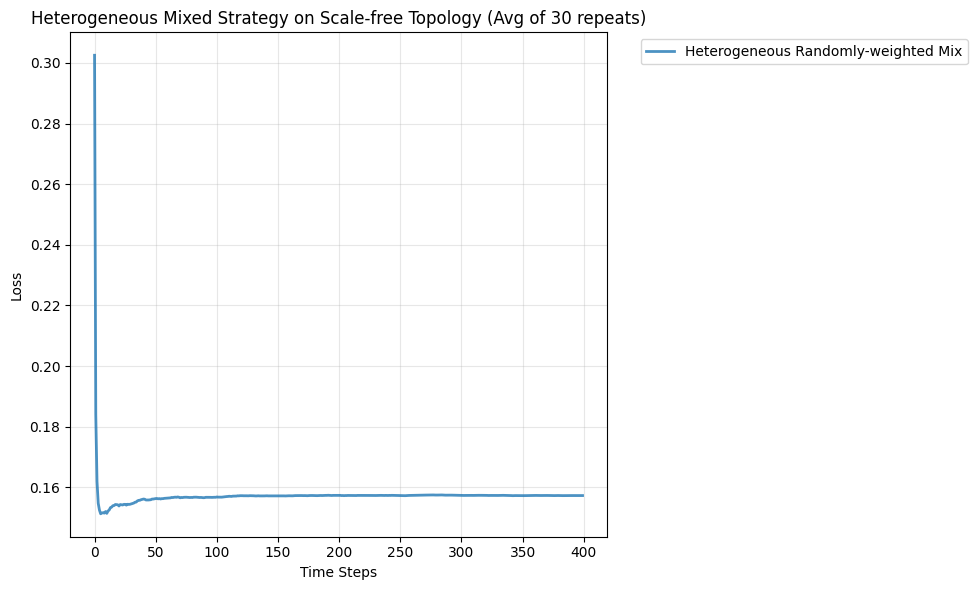

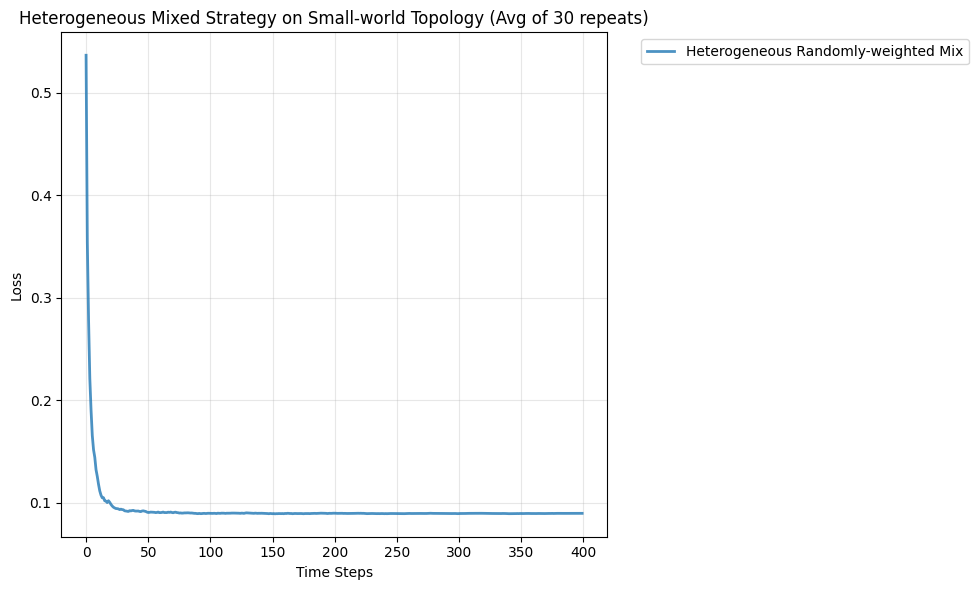

In [8]:
for graph_type in graph_types:
    plt.figure(figsize=(10, 6))

    for idx, mix_name in enumerate(all_results.keys()):
        states_array = np.array(all_results[mix_name][graph_type])
        avg_state = np.mean(states_array, axis=0)

        plt.plot(
            time_steps,
            avg_state[training_period:],
            label="Heterogeneous Randomly-weighted Mix",
            color=colors[idx % len(colors)],
            linewidth=2,
            alpha=0.8,
        )

    plt.xlabel("Time Steps")
    plt.ylabel("Loss")
    plt.title(f"Heterogeneous Mixed Strategy on {graph_type.capitalize()} Topology (Avg of {num_repeats} repeats)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [6]:
summary_data = []

for mix_name in all_results.keys():
    all_topologies_average = []

    for graph_type in graph_types:
        states_array = np.array(all_results[mix_name][graph_type])
        if states_array.size == 0:
            continue
        avg_state = np.mean(states_array, axis=0)
        all_topologies_average.append(avg_state)

    if len(all_topologies_average) == 0:
        final_avg_loss = float("nan")
    else:
        grand_average = np.mean(all_topologies_average, axis=0)
        final_avg_loss = np.mean(grand_average[training_period:])

    summary_data.append({
        "Strategy Mix": "Heterogeneous Randomly-weighted Mix",
        "Average Loss after 400 iterations": final_avg_loss,
    })

summary_df = pd.DataFrame(summary_data).sort_values("Average Loss after 400 iterations")
print(summary_df.to_string(index=False))


                       Strategy Mix  Average Loss after 400 iterations
Heterogeneous Randomly-weighted Mix                           0.120775
